
# Clean MLP overfitting sweep notebook

This notebook keeps only the components needed to answer:

**For each permutation length `n`, at what MLP width does the model start to overfit?**

It does four things:
1. generate random-walk training/test data,
2. train an MLP for each `(n, width)` pair,
3. compare train vs. test metrics,
4. summarize the overfitting threshold for each `n`.


In [1]:
print("hello world")

hello world


In [2]:

import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import r2_score, root_mean_squared_error
from scipy import stats

# -----------------------------
# Base config
# -----------------------------
CFG = {}
CFG['random_walks_type'] = 'non-backtracking-beam'   # 'simple' or 'non-backtracking-beam'
CFG['n_random_walks_to_generate'] = 20_000           # training samples generated each epoch, increased this for koltsov3 (was 10000)
CFG['n_random_walks_steps_back_to_ban'] = 8          # only used for non-backtracking-beam
CFG['n_epochs'] = 25                                 # increased this for koltsov3 (was 10)
CFG['batch_size'] = 1024
CFG['lr'] = 0.001
CFG['model_type'] = 'MLP'

# Graph family
CFG['graph_family'] = 'koltsov3'
CFG['koltsov3_k'] = 0   # uses S = (k, k+2)

# Sweep values
n_values = [8]
widths = [64]

# Evaluation settings
N_TEST_SAMPLES = 1024
RESULTS_CSV = 'koltsov3_mlp_width_n_overfit_sweep_clean.csv'
SUMMARY_CSV = 'koltsov3_mlp_width_n_overfit_summary_clean.csv'

# Reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


In [3]:
# -----------------------------
# Problem / random-walk helpers
# -----------------------------
def get_LRX_moves(n):
    L = np.array(list(np.arange(1, n)) + [0])
    R = np.array([n - 1] + list(np.arange(n - 1)))
    X = np.array([1, 0] + list(np.arange(2, n)))
    return [L, R, X]


def get_koltsov3_moves(n, k=0):
    """
    Koltsov3 generators on {0, 1, ..., n-1}:
      I = (0 1)(2 3)(4 5)...
      K = (1 2)(3 4)(5 6)...
      S = (k, k+2)

    For d = 2, these generate all of S_n.
    """
    if n < 3:
        raise ValueError("Koltsov3 with S=(k,k+2) requires n >= 3.")
    if not (0 <= k <= n - 3):
        raise ValueError(f"k must satisfy 0 <= k <= n-3, got k={k} for n={n}.")

    I = np.arange(n)
    K = np.arange(n)
    S = np.arange(n)

    # I = (0 1)(2 3)(4 5)...
    for i in range(0, n - 1, 2):
        I[i], I[i + 1] = I[i + 1], I[i]

    # K = (1 2)(3 4)(5 6)...
    for i in range(1, n - 1, 2):
        K[i], K[i + 1] = K[i + 1], K[i]

    # S = (k, k+2)
    S[k], S[k + 2] = S[k + 2], S[k]

    return [I, K, S]


def get_random_walk_length(n, graph_family):
    """
    Heuristic walk length.
    The old n(n-1)/2 choice was tied to the LRX setup.
    For Koltsov3, use a simple linear choice.
    """
    if graph_family == 'LRX':
        return int(n * (n - 1) / 2)
    elif graph_family == 'koltsov3':
        return 8 * n
    else:
        raise ValueError(f"Unknown graph_family: {graph_family}")


def build_problem(n, graph_family='LRX', koltsov3_k=0, device=device):
    if graph_family == 'LRX':
        list_generators = get_LRX_moves(n)
    elif graph_family == 'koltsov3':
        list_generators = get_koltsov3_moves(n, k=koltsov3_k)
    else:
        raise ValueError(f"Unknown graph_family: {graph_family}")

    dtype_generators = torch.int64
    state_destination = torch.arange(n, device=device, dtype=dtype_generators)
    dtype_state = torch.uint8 if n <= 256 else torch.uint16
    return list_generators, state_destination, dtype_state


def get_neighbors(states, moves):
    return torch.gather(
        states.unsqueeze(1).expand(states.size(0), moves.shape[0], states.size(1)),
        2,
        moves.unsqueeze(0).expand(states.size(0), moves.shape[0], states.size(1))
    )


def _normalize_generators(generators, device):
    if isinstance(generators, list):
        list_generators = generators
    elif isinstance(generators, tuple):
        list_generators = list(generators)
    elif isinstance(generators, torch.Tensor):
        list_generators = [list(generators[i, :]) for i in range(generators.shape[0])]
    else:
        raise TypeError("generators must be list, tuple, or torch.Tensor")

    moves = torch.tensor(np.array(list_generators), dtype=torch.long, device=device)
    return moves


def random_walks(
    generators,
    n_random_walk_length,
    n_random_walks_to_generate,
    n_random_walks_steps_back_to_ban,
    random_walks_type,
    state_rw_start,
    dtype_state,
    device=device
):
    moves = _normalize_generators(generators, device)
    n_generators = moves.shape[0]
    n = moves.shape[1]

    states = state_rw_start.unsqueeze(0).repeat(n_random_walks_to_generate, 1).to(dtype_state)
    y = torch.zeros(n_random_walks_to_generate, device=device, dtype=torch.float32)

    if random_walks_type == 'simple':
        for step in range(1, n_random_walk_length + 1):
            move_ids = torch.randint(0, n_generators, (n_random_walks_to_generate,), device=device)
            chosen_moves = moves[move_ids]
            states = torch.gather(states, 1, chosen_moves)
            y[:] = step / n_random_walk_length  # was step, modified to normalize across different values of n

    elif random_walks_type == 'non-backtracking-beam':
        move_history = []

        for step in range(1, n_random_walk_length + 1):
            allowed = torch.ones((n_random_walks_to_generate, n_generators), dtype=torch.bool, device=device)

            if len(move_history) > 0:
                recent_history = move_history[-n_random_walks_steps_back_to_ban:]
                for prev_moves in recent_history:
                    allowed.scatter_(1, prev_moves.unsqueeze(1), False)

            fallback_rows = ~allowed.any(dim=1)
            if fallback_rows.any():
                allowed[fallback_rows, :] = True

            move_ids = torch.zeros(n_random_walks_to_generate, dtype=torch.long, device=device)
            for i in range(n_random_walks_to_generate):
                choices = torch.where(allowed[i])[0]
                move_ids[i] = choices[torch.randint(len(choices), (1,), device=device)]

            move_history.append(move_ids.clone())
            chosen_moves = moves[move_ids]
            states = torch.gather(states, 1, chosen_moves)
            y[:] = step
    else:
        raise ValueError(f"Unknown random_walks_type: {random_walks_type}")

    return states, y

In [4]:

# -----------------------------
# Model and metric helpers
# -----------------------------
class Net(nn.Module):
    def __init__(self, input_size, hidden_dims, num_classes_for_one_hot):
        super().__init__()
        self.num_classes_for_one_hot = num_classes_for_one_hot
        in_features = input_size * num_classes_for_one_hot
        layers = []
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_features, hidden_dim))
            layers.append(nn.ReLU())
            in_features = hidden_dim
        layers.append(nn.Linear(in_features, 1))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        x = torch.nn.functional.one_hot(
            x.long(), num_classes=self.num_classes_for_one_hot
        ).float().flatten(start_dim=-2)
        return self.layers(x)


def get_model_inf(CFG):
    s = str(CFG['model_type'])
    for t in CFG['list_layers_sizes']:
        s += f'_{t}'
    s += f"_epochs{CFG['n_epochs']}"
    s += f"_rwlen{CFG['n_random_walk_length']}"
    s += f"_n_rw{CFG['n_random_walks_to_generate']}"
    return s


def evaluate_predictions(y_true, y_pred):
    return {
        'r2': r2_score(y_true, y_pred),
        'rmse': root_mean_squared_error(y_true, y_pred),
        'spearman': stats.spearmanr(y_true, y_pred).statistic,
    }


In [5]:

# -----------------------------
# Sweep runner
# -----------------------------
def run_overfit_sweep(n_values, widths, cfg=CFG, n_test_samples=N_TEST_SAMPLES):
    results = []

    random_walks_type = cfg['random_walks_type']
    n_random_walks_to_generate = cfg['n_random_walks_to_generate']
    n_random_walks_steps_back_to_ban = cfg['n_random_walks_steps_back_to_ban']
    n_epochs = cfg['n_epochs']
    batch_size = cfg['batch_size']
    lr = cfg['lr']

    for n in n_values:
        print(f'\n==============================')
        print(f'SWEEPING n = {n}')
        print(f'==============================')

        cfg['n_permutations_length'] = n
        cfg['n_random_walk_length'] = get_random_walk_length(n, cfg['graph_family'])
        cfg['input_size'] = n
        
        list_generators, state_destination, dtype_state = build_problem(
            n,
            graph_family=cfg['graph_family'],
            koltsov3_k=cfg['koltsov3_k']
        )

        X_test, y_test = random_walks(
            list_generators,
            n_random_walk_length=cfg['n_random_walk_length'],
            n_random_walks_to_generate=n_test_samples,
            n_random_walks_steps_back_to_ban=n_random_walks_steps_back_to_ban,
            random_walks_type=random_walks_type,
            state_rw_start=state_destination,
            dtype_state=dtype_state,
        )
        test_dataset = TensorDataset(X_test)
        test_loader = DataLoader(test_dataset, batch_size=batch_size)

        for width in widths:
            print(f'\n----- n={n}, width={width} -----')
            cfg['list_layers_sizes'] = [width]
            str_modeling_inf = get_model_inf(cfg)

            model = Net(
                input_size=n,
                hidden_dims=cfg['list_layers_sizes'],
                num_classes_for_one_hot=n,
            ).to(device)

            criterion = nn.MSELoss()
            optimizer = optim.Adam(model.parameters(), lr=lr)

            t_train_start = time.time()
            list_epoch_train_loss = []
            X_train_last = None
            y_train_last = None

            for epoch in range(n_epochs):
                X_train, y_train = random_walks(
                    list_generators,
                    n_random_walk_length=cfg['n_random_walk_length'],
                    n_random_walks_to_generate=n_random_walks_to_generate,
                    n_random_walks_steps_back_to_ban=n_random_walks_steps_back_to_ban,
                    random_walks_type=random_walks_type,
                    state_rw_start=state_destination,
                    dtype_state=dtype_state,
                )

                y_train = y_train.float()
                indices = torch.randperm(X_train.shape[0], device=X_train.device)
                X_train = X_train[indices]
                y_train = y_train[indices]

                X_train_last = X_train
                y_train_last = y_train

                model.train()
                n_states_all = X_train.shape[0]
                train_loss = 0.0
                cc = 0

                for i_start_batch in range(0, n_states_all, batch_size):
                    i_end_batch = min(i_start_batch + batch_size, n_states_all)
                    batch_X = X_train[i_start_batch:i_end_batch]
                    batch_y = y_train[i_start_batch:i_end_batch]

                    outputs = model(batch_X).squeeze()
                    loss = criterion(outputs, batch_y)

                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                    train_loss += loss.item()
                    cc += 1

                train_loss /= cc
                list_epoch_train_loss.append(train_loss)
                print(f'epoch {epoch}: train_loss={train_loss:.4f}')

            fit_time = time.time() - t_train_start

            model.eval()
            train_dataset = TensorDataset(X_train_last)
            train_loader = DataLoader(train_dataset, batch_size=batch_size)
            
            train_pred_list = []
            
            model.eval()
            # with torch.no_grad():
            #     train_pred = model(X_train_last).detach().cpu().numpy().ravel()
            with torch.no_grad():
                for batch in train_loader:
                    batch_X = batch[0].to(device)
                    batch_pred = model(batch_X)
                    train_pred_list.append(batch_pred.detach().cpu())
            
            train_pred = torch.cat(train_pred_list).numpy().ravel()

            y_train_true = y_train_last.detach().cpu().numpy().ravel()
            train_metrics = evaluate_predictions(y_train_true, train_pred)

            y_pred_list = []
            t_pred_start = time.time()
            with torch.no_grad():
                for batch in test_loader:
                    batch_X = batch[0].to(device)
                    batch_pred = model(batch_X)
                    y_pred_list.append(batch_pred.detach().cpu())
            predict_time = time.time() - t_pred_start

            y_pred = torch.cat(y_pred_list).numpy().ravel()
            y_true = y_test.detach().cpu().numpy().ravel()
            test_metrics = evaluate_predictions(y_true, y_pred)

            results.append({
                'n_permutations_length': n,
                'width': width,
                'layers': str(cfg['list_layers_sizes']),
                'model': str_modeling_inf,
                'final_train_loss': list_epoch_train_loss[-1],
                'train_r2': train_metrics['r2'],
                'train_rmse': train_metrics['rmse'],
                'train_spearman': train_metrics['spearman'],
                'test_r2': test_metrics['r2'],
                'test_rmse': test_metrics['rmse'],
                'test_spearman': test_metrics['spearman'],
                'rmse_gap': test_metrics['rmse'] - train_metrics['rmse'],
                'spearman_gap': train_metrics['spearman'] - test_metrics['spearman'],
                'fit_time_sec': fit_time,
                'predict_time_sec': predict_time,
                'n_epochs': n_epochs,
                'n_random_walks_to_generate': n_random_walks_to_generate,
                'n_random_walk_length': cfg['n_random_walk_length'],
                'graph_family': cfg['graph_family'],
                'koltsov3_k': cfg['koltsov3_k'] if cfg['graph_family'] == 'koltsov3' else None,
            })

    df = pd.DataFrame(results).sort_values(['n_permutations_length', 'width']).reset_index(drop=True)
    return df


In [6]:

# Run the full sweep
# This can take a while. For a quick smoke test, temporarily shrink n_values/widths or set CFG['n_epochs']=1.

df_combo_sweep = run_overfit_sweep(n_values=n_values, widths=widths, cfg=CFG)
display(df_combo_sweep)

df_combo_sweep.to_csv(RESULTS_CSV, index=False)
print(f'Saved detailed results to {RESULTS_CSV}')



SWEEPING n = 8

----- n=8, width=64 -----
epoch 0: train_loss=4067.4333
epoch 1: train_loss=3992.2343
epoch 2: train_loss=3860.8614
epoch 3: train_loss=3661.5322
epoch 4: train_loss=3394.1291
epoch 5: train_loss=3059.6481
epoch 6: train_loss=2669.0829
epoch 7: train_loss=2246.7158
epoch 8: train_loss=1818.4995
epoch 9: train_loss=1408.9377
epoch 10: train_loss=1034.9786
epoch 11: train_loss=713.4730
epoch 12: train_loss=458.6971
epoch 13: train_loss=273.3022
epoch 14: train_loss=150.0851
epoch 15: train_loss=75.5099
epoch 16: train_loss=34.8746
epoch 17: train_loss=14.8472
epoch 18: train_loss=5.9386
epoch 19: train_loss=2.2797
epoch 20: train_loss=0.9317
epoch 21: train_loss=0.4681
epoch 22: train_loss=0.3075
epoch 23: train_loss=0.2457
epoch 24: train_loss=0.2210


/tmp/ipykernel_26267/2911246334.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'spearman': stats.spearmanr(y_true, y_pred).statistic,
/tmp/ipykernel_26267/2911246334.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'spearman': stats.spearmanr(y_true, y_pred).statistic,


,n_permutations_length,width,layers,model,final_train_loss,train_r2,train_rmse,train_spearman,test_r2,test_rmse,test_spearman,rmse_gap,spearman_gap,fit_time_sec,predict_time_sec,n_epochs,n_random_walks_to_generate,n_random_walk_length,graph_family,koltsov3_k
0,8,64,[64],MLP_64_epochs25_rwlen64_n_rw20000,0.220992,0.0,0.459499,NaN,0.0,0.446107,NaN,-0.013391,NaN,1391.461085,0.002142,25,20000,64,koltsov3,0


Saved detailed results to koltsov3_mlp_width_n_overfit_sweep_clean.csv


In [9]:
def summarize_overfitting(df):
    summary_rows = []

    for n in sorted(df['n_permutations_length'].unique()):
        df_n = df[df['n_permutations_length'] == n].sort_values('width').reset_index(drop=True)

        best_test_rmse = float('inf')
        overfit_width_rmse = None
        best_test_spearman = -float('inf')
        overfit_width_spearman = None

        for _, row in df_n.iterrows():
            # RMSE logic
            if pd.notna(row['test_rmse']):
                if row['test_rmse'] < best_test_rmse:
                    best_test_rmse = row['test_rmse']
                elif overfit_width_rmse is None:
                    overfit_width_rmse = row['width']

            # Spearman logic
            if pd.notna(row['test_spearman']):
                if row['test_spearman'] > best_test_spearman:
                    best_test_spearman = row['test_spearman']
                elif overfit_width_spearman is None:
                    overfit_width_spearman = row['width']

        # Best RMSE row
        if df_n['test_rmse'].notna().any():
            best_rmse_row = df_n.loc[df_n['test_rmse'].idxmin()]
            best_width_by_rmse = best_rmse_row['width']
            best_test_rmse_val = best_rmse_row['test_rmse']
        else:
            best_width_by_rmse = None
            best_test_rmse_val = None

        # Best Spearman row
        if df_n['test_spearman'].notna().any():
            best_spear_row = df_n.loc[df_n['test_spearman'].idxmax()]
            best_width_by_spearman = best_spear_row['width']
            best_test_spearman_val = best_spear_row['test_spearman']
        else:
            best_width_by_spearman = None
            best_test_spearman_val = None
            overfit_width_spearman = None

        summary_rows.append({
            'n_permutations_length': n,
            'best_width_by_rmse': best_width_by_rmse,
            'best_test_rmse': best_test_rmse_val,
            'overfit_starts_by_rmse': overfit_width_rmse,
            'best_width_by_spearman': best_width_by_spearman,
            'best_test_spearman': best_test_spearman_val,
            'overfit_starts_by_spearman': overfit_width_spearman,
        })

    return pd.DataFrame(summary_rows)

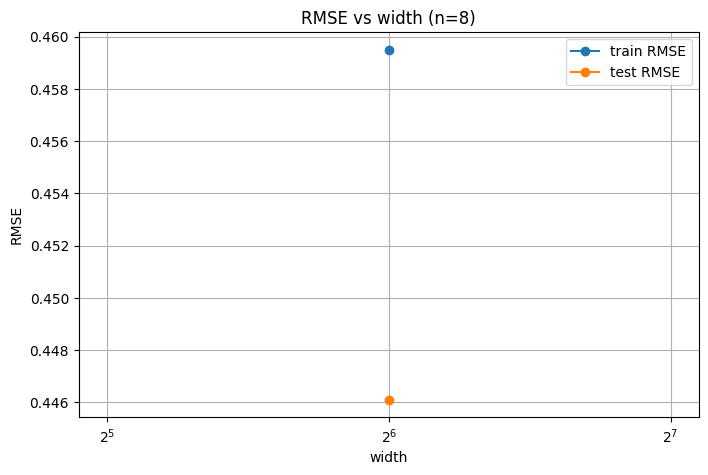

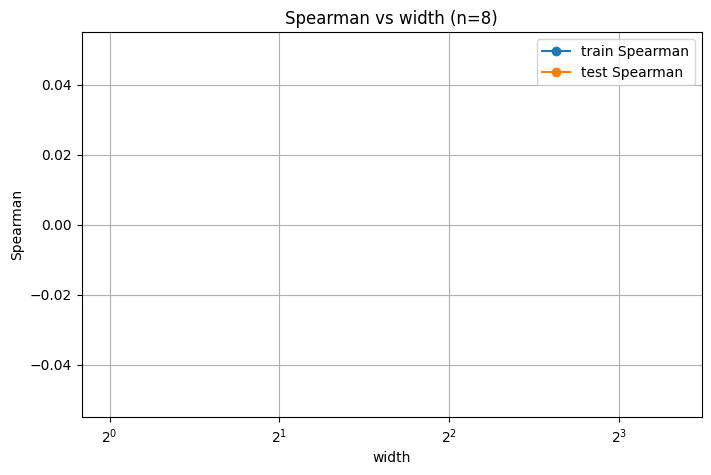

In [10]:

# -----------------------------
# Plots
# -----------------------------
for n in sorted(df_combo_sweep['n_permutations_length'].unique()):
    df_n = df_combo_sweep[df_combo_sweep['n_permutations_length'] == n].sort_values('width')

    plt.figure(figsize=(8, 5))
    plt.plot(df_n['width'], df_n['train_rmse'], marker='o', label='train RMSE')
    plt.plot(df_n['width'], df_n['test_rmse'], marker='o', label='test RMSE')
    plt.xscale('log', base=2)
    plt.title(f'RMSE vs width (n={n})')
    plt.xlabel('width')
    plt.ylabel('RMSE')
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(df_n['width'], df_n['train_spearman'], marker='o', label='train Spearman')
    plt.plot(df_n['width'], df_n['test_spearman'], marker='o', label='test Spearman')
    plt.xscale('log', base=2)
    plt.title(f'Spearman vs width (n={n})')
    plt.xlabel('width')
    plt.ylabel('Spearman')
    plt.grid(True)
    plt.legend()
    plt.show()



## Notes

- Overfitting starts where **training keeps improving but test performance starts getting worse**.
- `test_rmse` is lower-is-better.
- `test_spearman` is higher-is-better.
- Because training data is regenerated each epoch, the exact threshold may move a bit from run to run. For a more stable estimate, repeat the sweep 2–3 times and average.
- For a faster pilot run, reduce `n_values`, `widths`, `CFG['n_epochs']`, or `CFG['n_random_walks_to_generate']`.
